In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min';Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [15]:
# #MAKING W HORIZONTAL AVERAGES EVERYWHERE
# def match_xlim_from_axes(axes):
#     """Set consistent x-limits for all axes based on the plotted data."""
#     all_xdata = []
#     for ax in axes:
#         for line in ax.lines:
#             all_xdata.extend(line.get_xdata())
    
#     if all_xdata:
#         xmin = min(all_xdata)
#         xmax = max(all_xdata)
#         for ax in axes:
#             ax.set_xlim(xmin, xmax)
            
# def MakeWPlots(data):
#     times = data['time']
#     time_indices = range(0, len(times), 5)
    
#     n_plots = len(time_indices)
#     ncols = 5
#     nrows = int(np.ceil(n_plots / ncols))
    
#     fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows), sharey=True)
#     axes = axes.flatten()
    
#     for i, t in enumerate(time_indices):
#         if t % 20 == 0: print(t)
        
#         out = data['winterp'].isel(time=t).mean(dim=('xh', 'yh'))
#         axes[i].plot(out, data['zh'])
#         axes[i].set_title(f"t = {t}")
#         apply_scientific_notation([axes[i]])

#     match_xlim_from_axes(axes)

#     # Optional: hide unused subplots
#     # for j in range(i + 1, len(axes)):
#     #     axes[j].axis('off')

#     fig.suptitle('W Profiles')
#     plt.tight_layout()
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# MakeWPlots(data)
# # ######
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_nowarmbubble.nc') #***
# MakeWPlots(data)
# ######
# # dir2='/home/air673/koa_scratch/'
# # data=xr.open_dataset(dir2+'cm1out_noopenBCs.nc') #***
# # MakeWPlots(data)

In [ ]:
# def MakeWPlots_CU(data):
#     times = data['time']
#     time_indices = range(0, len(times), 5)
    
#     n_plots = len(time_indices)
#     ncols = 5
#     nrows = int(np.ceil(n_plots / ncols))
    
#     fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows), sharey=True)
#     axes = axes.flatten()
    
#     for i, t in enumerate(time_indices):
#         w = data['winterp'].isel(time=t)
#         qcqi = data['qc'].isel(time=t) + data['qi'].isel(time=t)
#         mask = (w > 0.5) & (qcqi >= 1e-6)
        
#         w_masked = w.where(mask)
#         out = w_masked.mean(dim=('xh', 'yh'))
    
#         axes[i].plot(out, data['zh'])
#         axes[i].set_title(f"t = {t}")
#         apply_scientific_notation([axes[i]])

#     # match_xlim_from_axes(axes)

#     # Optional: hide unused subplots
#     # for j in range(i + 1, len(axes)):
#     #     axes[j].axis('off')

#     fig.suptitle('W Cloudy Updraft Profiles')
#     plt.tight_layout()
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# MakeWPlots_CU(data)
# ######
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_nowarmbubble.nc') #***
# MakeWPlots_CU(data)
# #####
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_noopenBCs.nc') #***
# MakeWPlots_CU(data)

In [17]:
#MAKING W HORIZONTAL AVERAGES EVERYWHERE
def match_xlim_from_axes(axes):
    """Set consistent x-limits for all axes based on the plotted data."""
    all_xdata = []
    for ax in axes:
        for line in ax.lines:
            all_xdata.extend(line.get_xdata())
    
    if all_xdata:
        xmin = min(all_xdata)
        xmax = max(all_xdata)
        for ax in axes:
            ax.set_xlim(xmin, xmax)
            
def MakeWPlots(data):
    times = data['time']
    time_indices = range(0, len(times), 5)
    
    n_plots = len(time_indices)
    ncols = 5
    nrows = int(np.ceil(n_plots / ncols))
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows), sharey=True)
    axes = axes.flatten()
    
    for i, t in enumerate(time_indices):
        if t % 20 == 0: print(t)
        w = data['winterp'].isel(time=t);rho = data['rho'].isel(time=t)
        product=rho*w
        out = product.mean(dim=('xh', 'yh'))
        axes[i].plot(out, data['zh'])
        axes[i].set_title(f"t = {t}")
        apply_scientific_notation([axes[i]])

    match_xlim_from_axes(axes)

    # Optional: hide unused subplots
    # for j in range(i + 1, len(axes)):
    #     axes[j].axis('off')

    fig.suptitle('rho*W Profiles')
    plt.tight_layout()
    
    


0
20
40
60
80
100
120


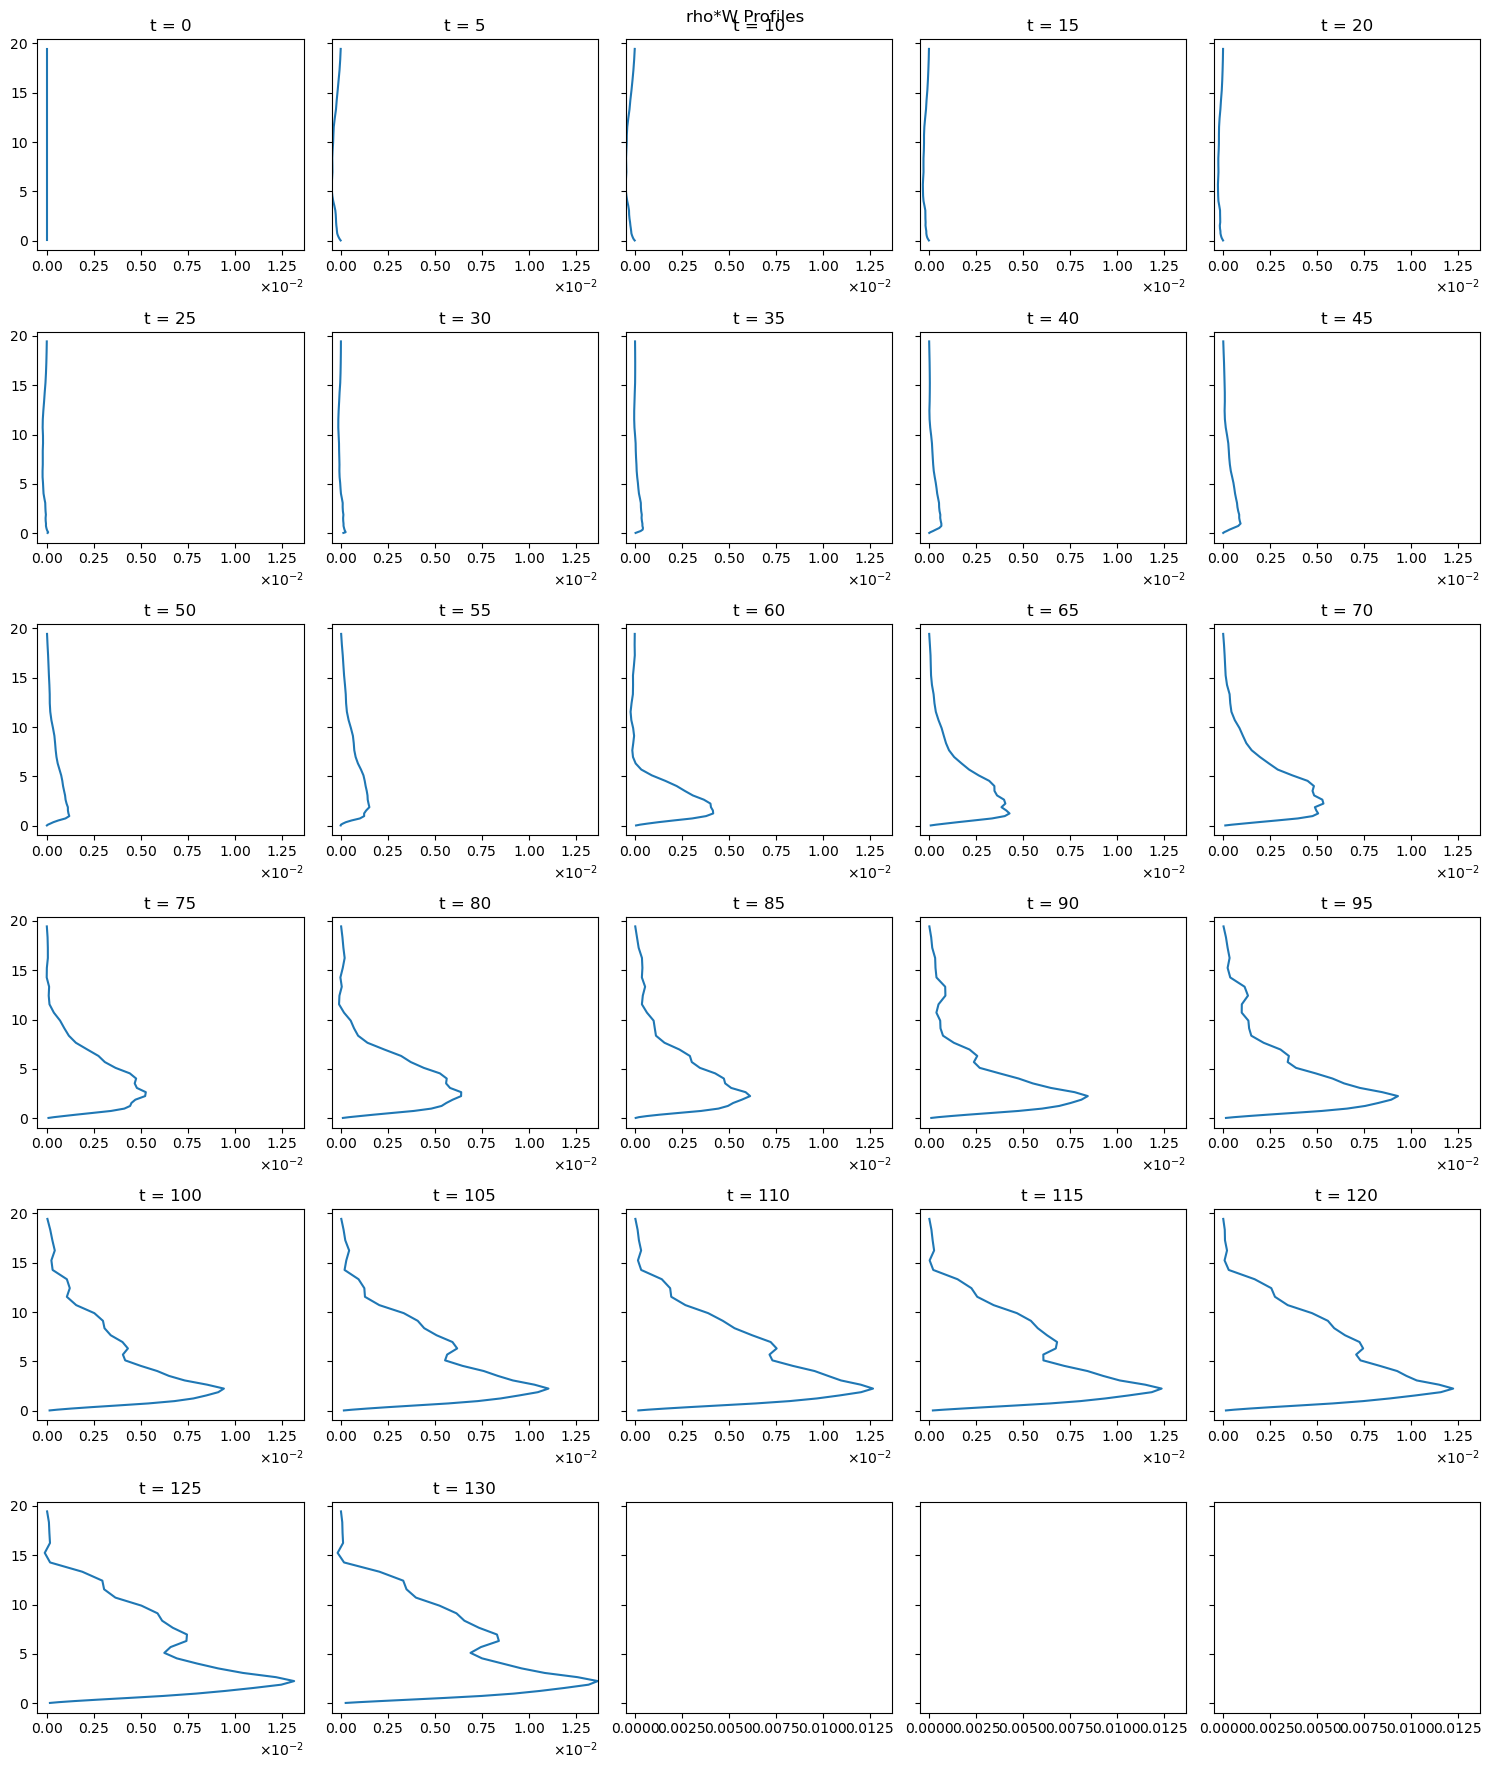

In [19]:
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
MakeWPlots(data)
# # ######
# # dir2='/home/air673/koa_scratch/'
# # data=xr.open_dataset(dir2+'cm1out_nowarmbubble.nc') #***
# # MakeWPlots(data)
# # #####
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_noopenBCs.nc') #***
# MakeWPlots(data)